# Heart Disease Prediction

This notebook explores the Heart Disease dataset, performs data preprocessing and EDA, and prepares the data for modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score
import optuna
import joblib
import os
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
# Load the datasets
try:
    train_df = pd.read_csv('dataset/train.csv')
    test_df = pd.read_csv('dataset/test.csv')
except FileNotFoundError:
    print("Error: Files not found. Please ensure 'train.csv' and 'test.csv' are in the same directory.")

In [3]:
# Display the first few rows of the training data
train_df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [4]:
# Check data types and missing values
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [5]:
train_df.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


## 1. Data Preprocessing

In [6]:
# Drop 'id' column as it's not a feature
if 'id' in train_df.columns:
    train_df = train_df.drop('id', axis=1)
if 'id' in test_df.columns:
    test_id = test_df['id'] # Save for submission
    test_df = test_df.drop('id', axis=1)

In [7]:
# Check for missing values
print("Missing values in Train set:")
print(train_df.isnull().sum())
print("\nMissing values in Test set:")
print(test_df.isnull().sum())

Missing values in Train set:
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

Missing values in Test set:
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
dtype: int64


### Encoding

In [8]:
# Encode Target Variable
train_df['Heart Disease'] = train_df['Heart Disease'].map({'Presence': 1, 'Absence': 0})

# Verify encoding
train_df['Heart Disease'].value_counts()

Heart Disease
0    347546
1    282454
Name: count, dtype: int64

Split data to avoid Data Leakage

In [9]:
X_train_df = train_df.drop('Heart Disease',axis=1)
y_train_df = train_df['Heart Disease']
X_train, X_test, y_train, y_test = train_test_split(X_train_df,y_train_df,test_size=0.2,stratify=y_train_df,random_state=42)

In [10]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(504000, 13) (126000, 13) (504000,) (126000,)


In [11]:
X_train.astype(int,float).columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium'],
      dtype='object')

In [12]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 504000 entries, 539041 to 261178
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      504000 non-null  int64  
 1   Sex                      504000 non-null  int64  
 2   Chest pain type          504000 non-null  int64  
 3   BP                       504000 non-null  int64  
 4   Cholesterol              504000 non-null  int64  
 5   FBS over 120             504000 non-null  int64  
 6   EKG results              504000 non-null  int64  
 7   Max HR                   504000 non-null  int64  
 8   Exercise angina          504000 non-null  int64  
 9   ST depression            504000 non-null  float64
 10  Slope of ST              504000 non-null  int64  
 11  Number of vessels fluro  504000 non-null  int64  
 12  Thallium                 504000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 53.8 MB


In [13]:
import numpy as np

# Columns that have extreme outliers
outlier_columns = ['Cholesterol', 'BP', 'Max HR']

for col in outlier_columns:
    # Learn limits ONLY from the training set
    lower_limit = X_train[col].quantile(0.01)
    upper_limit = X_train[col].quantile(0.99)
    
    # Cap training data
    X_train[col] = np.clip(X_train[col], lower_limit, upper_limit)
    
    # Cap test data using training limits
    X_test[col] = np.clip(X_test[col], lower_limit, upper_limit)


In [14]:
# Create interactions for Train
X_train['Age_HR_Interaction'] = X_train['Age'] * X_train['Max HR']
X_train['BP_Cholesterol_Risk'] = X_train['BP'] * X_train['Cholesterol']

# Create interactions for Test
X_test['Age_HR_Interaction'] = X_test['Age'] * X_test['Max HR']
X_test['BP_Cholesterol_Risk'] = X_test['BP'] * X_test['Cholesterol']


In [15]:
import pandas as pd

# Define binning logic as a helper block
def add_clinical_bins(df):
    df = df.copy() # Avoid SettingWithCopyWarning
    df['Age_Group'] = pd.cut(df['Age'], bins=[0, 45, 60, 100], labels=['Young', 'Middle', 'Senior'])
    df['Cholesterol_Level'] = pd.cut(df['Cholesterol'], bins=[0, 200, 240, 1000], labels=['Normal', 'Borderline', 'High'])
    df['BP_Level'] = pd.cut(df['BP'], bins=[0, 120, 130, 300], labels=['Normal', 'Elevated', 'High'])
    return df

X_train = add_clinical_bins(X_train)
X_test = add_clinical_bins(X_test)


In [16]:
# Columns to encode: existing categorical + the new bins we just made
categorical_columns = ['Chest pain type', 'EKG results', 'Slope of ST', 'Thallium', 
                       'Age_Group', 'Cholesterol_Level', 'BP_Level']

# Apply One-Hot Encoding
X_train = pd.get_dummies(X_train, columns=categorical_columns, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_columns, drop_first=True)

# Align the test set with the train set to prevent missing or mismatched columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


In [17]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data AND transform training data
# Note: We use the cleaned data from the previous step
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the SAME scaler (do not fit on test data!)
# Note: X_test was implicitly defined in your earlier split. 
# If you haven't removed outliers from X_test, that's generally fine/preferred for testing 
# to show how the model handles 'real' messy data.
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for easier viewing (optional, but helpful)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Scaling complete.")
print("X_train_scaled mean:\n", X_train_scaled.mean().head()) # Should be close to 0
print("X_train_scaled std:\n", X_train_scaled.std().head())   # Should be close to 1

import joblib
joblib.dump(scaler, 'models/scaler.joblib')
print("✅ Scaler saved to models/scaler.joblib")

Scaling complete.
X_train_scaled mean:
 Age            -3.022062e-16
Sex            -1.192133e-16
BP             -8.006012e-16
Cholesterol     4.131862e-16
FBS over 120    4.511382e-17
dtype: float64
X_train_scaled std:
 Age             1.000001
Sex             1.000001
BP              1.000001
Cholesterol     1.000001
FBS over 120    1.000001
dtype: float64
✅ Scaler saved to models/scaler.joblib


In [41]:
X_train = X_train_scaled
X_test = X_test_scaled

In [42]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(504000, 26) (126000, 26) (504000,) (126000,)


In [43]:
# Initialize results list to store model performance
results = []

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("Training Logistic Regression...")
lr_model = LogisticRegression(random_state=42,max_iter=5000)
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
y_prob = lr_model.predict_proba(X_test)[:, 1]  # probability of class 1
roc_auc = roc_auc_score(y_test, y_prob)

results.append({'Model': 'Logistic Regression', 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC_AUC':roc_auc, 'Object': lr_model})

print("\n--- Logistic Regression ---")
print(classification_report(y_test, y_pred))

Training Logistic Regression...

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.86      0.87     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.88      0.88    126000
weighted avg       0.89      0.89      0.89    126000



In [45]:
from sklearn.tree import DecisionTreeClassifier

print("Training Decision Tree...")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
y_prob = dt_model.predict_proba(X_test)[:, 1]  # probability of class 1
roc_auc = roc_auc_score(y_test, y_prob)

results.append({'Model': 'Decision Tree', 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC_AUC':roc_auc,'Object': dt_model})

print("\n--- Decision Tree ---")
print(classification_report(y_test, y_pred))

Training Decision Tree...

--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.84      0.84      0.84     69509
           1       0.81      0.81      0.81     56491

    accuracy                           0.83    126000
   macro avg       0.82      0.82      0.82    126000
weighted avg       0.83      0.83      0.83    126000



In [46]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest...")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
y_prob = rf_model.predict_proba(X_test)[:, 1]  # probability of class 1
roc_auc = roc_auc_score(y_test, y_prob)

results.append({'Model': 'Random Forest', 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC_AUC':roc_auc, 'Object': rf_model})

print("\n--- Random Forest ---")
print(classification_report(y_test, y_pred))

Training Random Forest...

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.89      0.90      0.89     69509
           1       0.87      0.86      0.87     56491

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000



In [47]:
from xgboost import XGBClassifier

print("Training XGBoost...")
# XGBoost Tuned
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=8000,
    learning_rate=0.03,
    max_depth=5,
    eval_metric='auc',
    early_stopping_rounds=100,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)],verbose=False)
y_pred = xgb_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
y_prob = xgb_model.predict_proba(X_test)[:, 1]  # probability of class 1
roc_auc = roc_auc_score(y_test, y_prob)

results.append({'Model': 'XGBoost', 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC_AUC':roc_auc, 'Object': xgb_model})

print("\n--- XGBoost ---")
print(classification_report(y_test, y_pred))

Training XGBoost...

--- XGBoost ---
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.87      0.88     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000



In [48]:
# LightGBM
from lightgbm import LGBMClassifier

print("Training LightGBM...")
lgbm_model = LGBMClassifier(
    n_estimators=8000,
    learning_rate=0.03,
    max_depth=5,
    objective='binary',
    metric='auc',
    early_stopping_rounds=100,
    random_state=42,
    verbosity=-1
)
lgbm_model.fit(X_train, y_train, eval_set=[(X_test, y_test)])
y_pred = lgbm_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
y_prob = lgbm_model.predict_proba(X_test)[:, 1]  # probability of class 1
roc_auc = roc_auc_score(y_test, y_prob)

results.append({'Model': 'LightGBM', 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC_AUC':roc_auc, 'Object': lgbm_model})

print("\n--- LightGBM ---")
print(classification_report(y_test, y_pred))

Training LightGBM...

--- LightGBM ---
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.87      0.88     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000



In [49]:
# CatBoost
from catboost import CatBoostClassifier

print("Training CatBoost...")
catb_model = CatBoostClassifier(
    n_estimators=8000,
    learning_rate=0.03,
    max_depth=5,
    early_stopping_rounds=400,
    eval_metric='AUC',
    random_state=42,
    verbose=False
)
catb_model.fit(X_train, y_train, eval_set=(X_test, y_test))
y_pred = catb_model.predict(X_test)
y_prob = catb_model.predict_proba(X_test)[:, 1]  # probability of class 1
roc_auc = roc_auc_score(y_test, y_prob)

# results.append({'Model': 'CatBoost', 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC_AUC':roc_auc, 'Object': catb_model})

print("\n--- CatBoost ---")
print(classification_report(y_test, y_pred))

Training CatBoost...

--- CatBoost ---
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.87      0.88     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000



In [50]:
# Import CatBoost
from catboost import CatBoostClassifier
import optuna
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

# Define the Optuna objective function for CatBoost
def objective(trial):
    """
    Optuna objective function to optimize CatBoost hyperparameters
    """
    # Suggest hyperparameters
    params = {
        'iterations': trial.suggest_int('iterations', 500, 3000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_float('random_strength', 0, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 5),
        
        # Fixed parameters
        'task_type': 'GPU',  # Use GPU
        'devices': '0',  # GPU device ID
        'verbose': False,
        'random_state': 42,
        'eval_metric': 'AUC',
        'early_stopping_rounds': 50
    }
    
    # Create CatBoost model
    model = CatBoostClassifier(**params)
    
    # Train the model with validation set
    model.fit(
        X_train, y_train,
        eval_set=(X_test, y_test),
        verbose=False
    )
    
    # Make predictions
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate ROC-AUC score (optimization metric)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    return roc_auc

# Create Optuna study
print("Starting Optuna optimization for CatBoost...")
study = optuna.create_study(
    direction='maximize',  # Maximize ROC-AUC
    study_name='catboost_optimization',
    sampler=optuna.samplers.TPESampler(seed=42)
)

# Run optimization
study.optimize(
    objective, 
    n_trials=50,  # Number of trials (adjust based on your time/resources)
    timeout=3600,  # Optional: timeout in seconds (1 hour)
    show_progress_bar=True
)

# Print optimization results
print("\n" + "="*60)
print("Optimization Complete!")
print("="*60)
print(f"Best ROC-AUC Score: {study.best_value:.6f}")
print(f"Best Trial Number: {study.best_trial.number}")
print("\nBest Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-02-26 16:26:07,024] A new study created in memory with name: catboost_optimization


Starting Optuna optimization for CatBoost...


  0%|          | 0/50 [00:00<?, ?it/s]

Default metric period is 5 because AUC is/are not implemented for GPU


[I 2026-02-26 16:26:14,200] Trial 0 finished with value: 0.9555299065122516 and parameters: {'iterations': 1436, 'learning_rate': 0.2536999076681772, 'depth': 9, 'l2_leaf_reg': 6.387926357773329, 'border_count': 66, 'bagging_temperature': 0.15599452033620265, 'random_strength': 0.5808361216819946, 'scale_pos_weight': 4.46470458309974}. Best is trial 0 with value: 0.9555299065122516.


...

[I 2026-02-26 16:42:01,868] Trial 47 finished with value: 0.9559608903946033 and parameters: {'iterations': 1354, 'learning_rate': 0.0297073375029037, 'depth': 4, 'l2_leaf_reg': 9.640006102847666, 'border_count': 63, 'bagging_temperature': 0.2507242953070472, 'random_strength': 5.227449761537953, 'scale_pos_weight': 1.8654658513058708}. Best is trial 41 with value: 0.9562003638873888.


Default metric period is 5 because AUC is/are not implemented for GPU


[I 2026-02-26 16:42:13,558] Trial 48 finished with value: 0.9561989461332685 and parameters: {'iterations': 1826, 'learning_rate': 0.2210251829913458, 'depth': 5, 'l2_leaf_reg': 8.924872993165584, 'border_count': 100, 'bagging_temperature': 0.4831923477715354, 'random_strength': 4.7825715431024935, 'scale_pos_weight': 2.0251715214429784}. Best is trial 41 with value: 0.9562003638873888.


Default metric period is 5 because AUC is/are not implemented for GPU


[I 2026-02-26 16:42:17,901] Trial 49 finished with value: 0.9561046076739215 and parameters: {'iterations': 1829, 'learning_rate': 0.25795259376532703, 'depth': 5, 'l2_leaf_reg': 8.010213458023394, 'border_count': 103, 'bagging_temperature': 0.4967396164899705, 'random_strength': 6.482025835094307, 'scale_pos_weight': 1.484307043697285}. Best is trial 41 with value: 0.9562003638873888.

Optimization Complete!
Best ROC-AUC Score: 0.956200
Best Trial Number: 41

Best Hyperparameters:
  iterations: 1623
  learning_rate: 0.15852199413036414
  depth: 4
  l2_leaf_reg: 9.505994796613438
  border_count: 78
  bagging_temperature: 0.2525892468461163
  random_strength: 4.2185692682184746
  scale_pos_weight: 1.9630860214614314


In [ ]:
# Train final model with best parameters
print("\n" + "="*60)
print("Training Final CatBoost Model with Best Parameters...")
print("="*60)

best_params = study.best_params.copy()
best_params.update({
    'task_type': 'GPU',
    'devices': '0',
    'verbose': 100,
    'random_state': 42,
    'eval_metric': 'AUC',
    'early_stopping_rounds': 50
})

catb_model = CatBoostClassifier(**best_params)
catb_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    verbose=100
)

# Evaluate the final model
y_pred = catb_model.predict(X_test)
y_pred_proba = catb_model.predict_proba(X_test)[:, 1]
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n" + "="*60)
print("Final Model Performance")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.6f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.6f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.6f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Save the best model
print("\nSaving the best model...")
catb_model.save_model('models/catboost_best_model.cbm')
print("Model saved as 'catboost_best_model.cbm'")

results.append({'Model': 'CatBoost', 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC_AUC':roc_auc, 'Object': catb_model})


Training Final CatBoost Model with Best Parameters...


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9193088	best: 0.9193088 (0)	total: 14.9ms	remaining: 24.2s
100:	test: 0.9552031	best: 0.9552031 (100)	total: 1.44s	remaining: 21.7s
200:	test: 0.9558758	best: 0.9558758 (200)	total: 2.85s	remaining: 20.2s
300:	test: 0.9560577	best: 0.9560577 (300)	total: 4.07s	remaining: 17.9s
400:	test: 0.9561029	best: 0.9561052 (367)	total: 11.3s	remaining: 34.4s
500:	test: 0.9561418	best: 0.9561436 (498)	total: 12.5s	remaining: 27.9s
600:	test: 0.9561660	best: 0.9561676 (592)	total: 13.7s	remaining: 23.2s
bestTest = 0.9561676383
bestIteration = 592
Shrink model to first 593 iterations.

Final Model Performance
Accuracy: 0.882437
F1 Score: 0.874874
ROC-AUC Score: 0.956168

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89     69509
           1       0.84      0.92      0.87     56491

    accuracy                           0.88    126000
   macro avg       0.88      0.89      0.88    126000
weighted avg       0.89    

C:\Users\Vivek\AppData\Local\Temp\ipykernel_25016\3639473183.py:4: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study)


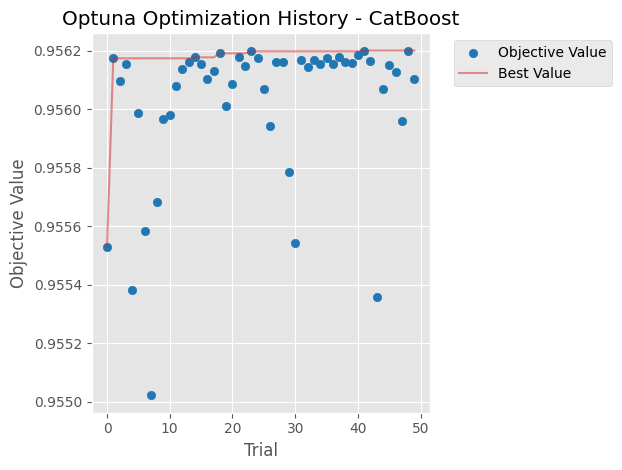

C:\Users\Vivek\AppData\Local\Temp\ipykernel_25016\3639473183.py:10: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_param_importances(study)


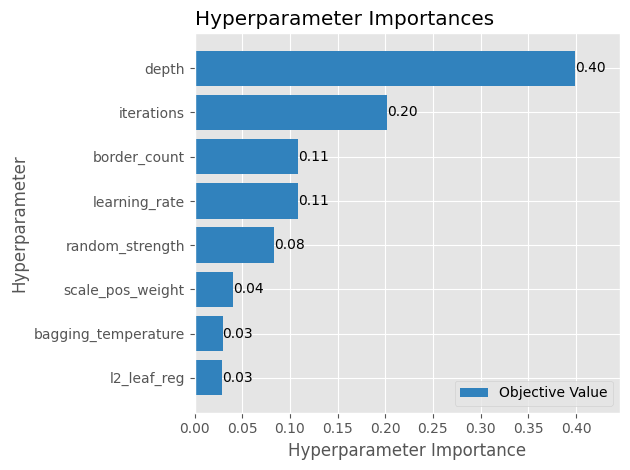

In [57]:
# Optional: Visualize optimization history
import matplotlib.pyplot as plt

fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title('Optuna Optimization History - CatBoost')
plt.tight_layout()
plt.show()

# Optional: Plot parameter importances
fig = optuna.visualization.matplotlib.plot_param_importances(study)
# plt.title('Hyperparameter Importances - CatBoost')
plt.tight_layout()
plt.show()

In [53]:
import pandas as pd

# Display Comparison
results_df = pd.DataFrame(results).sort_values(by=['ROC_AUC'], ascending=False)
display(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1','ROC_AUC']])

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
5,CatBoost,0.882437,0.836689,0.916712,0.874874,0.956166
3,XGBoost,0.889659,0.883883,0.867908,0.875823,0.955962
4,LightGBM,0.889468,0.883778,0.867554,0.875591,0.955935
0,Logistic Regression,0.886452,0.882892,0.860934,0.871775,0.953576
2,Random Forest,0.881444,0.873887,0.859624,0.866696,0.947742
1,Decision Tree,0.826452,0.805877,0.807403,0.806639,0.824667


In [54]:
# Select Best Model
best_model_name = results_df.iloc[0]['Model']
print(f"Best Model optimized for Recall: {best_model_name}")

Best Model optimized for Recall: CatBoost


In [59]:
import numpy as np

# ---------------------------------------------------------
# 1. Load test data
# ---------------------------------------------------------
test_df = pd.read_csv('dataset/test.csv')
test_id = test_df['id']
test_features = test_df.drop('id', axis=1)

# ---------------------------------------------------------
# 2. Apply Feature Engineering to test_features
# ---------------------------------------------------------

# A. Handle Outliers (FIXED: Recalculating limits from original train CSV)
# We load just those 3 columns from train.csv to get the exact original limits
original_train = pd.read_csv('dataset/train.csv', usecols=['Cholesterol', 'BP', 'Max HR'])

outlier_columns = ['Cholesterol', 'BP', 'Max HR']
for col in outlier_columns:
    # Calculate limits from the completely raw, original training dataset
    lower_limit = original_train[col].quantile(0.01)
    upper_limit = original_train[col].quantile(0.99)
    # Apply those limits to the test dataset
    test_features[col] = np.clip(test_features[col], lower_limit, upper_limit)

# B. Derived Interaction Features
test_features['Age_HR_Interaction'] = test_features['Age'] * test_features['Max HR']
test_features['BP_Cholesterol_Risk'] = test_features['BP'] * test_features['Cholesterol']

# C. Binning Continuous Variables
test_features['Age_Group'] = pd.cut(test_features['Age'], bins=[0, 45, 60, 100], labels=['Young', 'Middle', 'Senior'])
test_features['Cholesterol_Level'] = pd.cut(test_features['Cholesterol'], bins=[0, 200, 240, 1000], labels=['Normal', 'Borderline', 'High'])
test_features['BP_Level'] = pd.cut(test_features['BP'], bins=[0, 120, 130, 300], labels=['Normal', 'Elevated', 'High'])

# D. One-Hot Encoding Categorical Variables
categorical_columns = ['Chest pain type', 'EKG results', 'Slope of ST', 'Thallium', 
                       'Age_Group', 'Cholesterol_Level', 'BP_Level']

test_features = pd.get_dummies(test_features, columns=categorical_columns, drop_first=True)

# E. Align columns with training data 
# We align using X_train, which is currently a DataFrame in your notebook memory
# representing the final columns the model trained on (even if it's currently scaled)
X_train_dummy = pd.DataFrame(columns=X_train.columns) # create an empty df with exact columns
X_train_dummy, test_features = X_train_dummy.align(test_features, join='left', axis=1, fill_value=0)

# ---------------------------------------------------------
# 3. Scale and Predict
# ---------------------------------------------------------
# Scale the newly engineered test features
test_features_scaled = scaler.transform(test_features)

# Predict probabilities using your trained CatBoost model
test_probs = catb_model.predict_proba(test_features_scaled)[:, 1]

# ---------------------------------------------------------
# 4. Create submission
# ---------------------------------------------------------
submission = pd.DataFrame({
    'id': test_id,
    'Heart Disease': test_probs
})

submission.to_csv('submission.csv', index=False)
print("✅ submission.csv saved!")
submission.head()

✅ submission.csv saved!


,id,Heart Disease
0,630000,0.971397
1,630001,0.013717
2,630002,0.994354
3,630003,0.007441
4,630004,0.333168
